# Backpropagation Tutorial

**(C) 2019-2024 by [Damir Cavar](http://damir.cavar.me/)**

**Version:** 0.3, January 2024

**Download:** This and various other Jupyter notebooks are available from my [GitHub repo](https://github.com/dcavar/python-tutorial-for-ipython).

## Introduction

For more details on Backpropagation and its use in Neural Networks see Rumelhart, Hinton, and Williams (1986a) and Rumelhart, Hinton & Williams (1986b). A detailed overview is also provided in Goodfellow, Bengio, and Courville (2016).

The ideas and initial versions of this Python-based notebook have been inspired by many open and public tutorials and articles, but in particular by these three:
- Andrew Trask (2015) [*A Neural Network in 11 lines of Python (Part 1)*](https://iamtrask.github.io/2015/07/12/basic-python-network/)
- Matt Mazur (2015) [*A Step by Step Backpropagation Example*](https://mattmazur.com/2015/03/17/a-step-by-step-backpropagation-example/)
- Arunava Chakraborty (2018) [*Derivative of the Sigmoid function*](https://towardsdatascience.com/derivative-of-the-sigmoid-function-536880cf918e)

A lot of code examples and discussion has been compiled here using these sources.

**Prerequisites:**

In [1]:
!pip install -U numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 92.0 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.3
    Uninstalling numpy-1.26.3:
      Successfully uninstalled numpy-1.26.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scipy 1.11.4 requires numpy<1.28.0,>=1.21.6, but you have numpy 2.2.4 which is incompatible.
pandapower 2.14.11 requires numpy<2.0, but you have numpy 2.2.4 which is incompatible.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.2.4 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.4 which is incompatible.
catboost 1.2.7 requires numpy<2.0,>=1.16.0, but you have numpy 2.2.4 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.2.4 which is incompatible.
matplotlib 3.8.2 requires numpy<2,>=1.21, but you

In [2]:
!pip install -U matplotlib

  Using cached numpy-1.26.4-cp312-cp312-macosx_11_0_arm64.whl.metadata (61 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 25.0 MB/s eta 0:00:00a 0:00:01
Using cached numpy-1.26.4-cp312-cp312-macosx_11_0_arm64.whl (13.7 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.4
    Uninstalling numpy-2.2.4:
      Successfully uninstalled numpy-2.2.4
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.8.2
    Uninstalling matplotlib-3.8.2:
      Successfully uninstalled matplotlib-3.8.2

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


### Preliminaries

This notebook uses [nbextensions](https://github.com/ipython-contrib/jupyter_contrib_nbextensions) with *python-markdown/main* enabled. These extensions might not work in Jupyter Lab, thus some variable references in the markdown cells might not display.

We will use [numpy](https://numpy.org/) in the following demo. Let us import it and assign the *np* alias to it:

In [3]:
import numpy as np

For plots of curves and functions we will use *pyplot* from *matplotlib*. We will import it here:

In [4]:
from matplotlib import pyplot as plt

## Non-linearity Function and Derivatives

The Sigmoid function is defined as:

$$\sigma(x) = \frac{1}{1 + e^{-x}} $$

We can specify it in Python as:

In [5]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

We can now plot the sigmoid function for x values between -10 and 10:

In [12]:
%matplotlib inline
x = np.arange(-10, 10, 0.2)
y = sigmoid(x)
fig = plt.figure()

<Figure size 640x480 with 0 Axes>

In [13]:
plt.figure()
ax = fig.add_axes([0, 0, 1, 1])
ax.plot(x, y)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Sigmoid")
print()

<Figure size 640x480 with 0 Axes>

In the following for Backpropagation we will make use of the Derivative of the Sigmoid function. The Derivative of Sigmoid is defined as:

$$\frac{d}{dx}\sigma(x) = \sigma(x) (1 - \sigma(x))$$

We can derive this equation as follows. Assume that:

$$\frac{d}{dx} \sigma(x) = \frac{d}{dx}  \frac{1}{1 + e^{-x}} $$

We can invert the fraction using a negative exponent:

$$\frac{d}{dx} \sigma(x) = \frac{d}{dx}  \frac{1}{1 + e^{-x}} = \frac{d}{dx} (1 + e^{-x})^{-1}$$

We can apply the *reciprocal rule*, which is, the numerator is the derivative of the function ($g'(x)$) times -1 divided by the square of the denominator $g(x)$:

$$\frac{d}{dx} \left[ \frac{1}{g(x)} \right] = \frac{-g'(x)}{[g(x)]^2} = -g(x)^{-2} g'(x)$$

In our Derivative of Sigmoid derivation, we can now reformulate as:

$$\frac{d}{dx} (1 + e^{-x})^{-1} = -(1 + e^{-x})^{-2} \frac{d}{dx} (1 + e^{-x})$$

With $\alpha$ and $\beta$ constants, the *Rule of Linearity* says that:

$$\frac{d}{dx} \left( \alpha f(x) + \beta g(x) \right) = \frac{d}{dx} \left( \alpha f(x) \right) + \frac{d}{dx} \left( \beta g(x) \right) = \alpha f'(x) + \beta g'(x)$$

This means, using the Rule of Linearity and given that the derivative of a constant is 0, we can rewrite our equation as:

$$\frac{d}{dx} (1 + e^{-x})^{-1} = -(1 + e^{-x})^{-2} \frac{d}{dx} (1 + e^{-x}) = -(1 + e^{-x})^{-2} \left( \frac{d}{dx}[1] + \frac{d}{dx}[e^{-x}] \right) = -(1 + e^{-x})^{-2} \left( 0 + \frac{d}{dx}[e^{-x}] \right) = -(1 + e^{-x})^{-2} \frac{d}{dx}[e^{-x}] $$

The *Exponential Rule* says that:

$$\frac{d}{dx} e^{u(x)} = e^{u(x)} \frac{d}{dx} x$$

We can thus rewrite:

$$\frac{d}{dx} (1 + e^{-x})^{-1} = -(1 + e^{-x})^{-2} e^{-x} \frac{d}{dx}[-x] $$

This is equivalent to:

$$\frac{d}{dx} (1 + e^{-x})^{-1} = -(1 + e^{-x})^{-2} e^{-x} -\frac{d}{dx}[x]$$

Given that a derivative of a variable is 1, we can rewrite as:

$$\frac{d}{dx} (1 + e^{-x})^{-1} = -(1 + e^{-x})^{-2} e^{-x} -1 = (1 + e^{-x})^{-2} e^{-x} = \frac{e^{-x}}{(1 + e^{-x})^2}$$

We can rewrite the derivative as:

$$\frac{d}{dx} (1 + e^{-x})^{-1} = \frac{1 e^{-x}}{(1 + e^{-x}) (1 + e^{-x})} = \frac{1}{1 + e^{-x}} \frac{e^{-x}}{1 + e^{-x}} = \frac{1}{1 + e^{-x}} \frac{e^{-x} + 1 - 1}{1 + e^{-x}} = \frac{1}{1 + e^{-x}} \left( \frac{1 + e^{-x}}{1 + e^{-x}} - \frac{1}{1 + e^{-x}} \right)$$

We can simplify this to:

$$\frac{d}{dx} (1 + e^{-x})^{-1} = \frac{1}{1 + e^{-x}} \left( 1 - \frac{1}{1 + e^{-x}} \right)$$

This means that we can derive the Derivative of the Sigmoid function as:

$$\frac{d}{dx} \sigma(x) = \sigma(x) ( 1 - \sigma(x) )$$

We can specify the Python function of the Derivative of the Sigmoid function as:

In [14]:
def sigmoidDerivative(x):
    return sigmoid(x) * (1 - sigmoid(x))

We can plot the Derivative of the Sigmoid Function as follows:

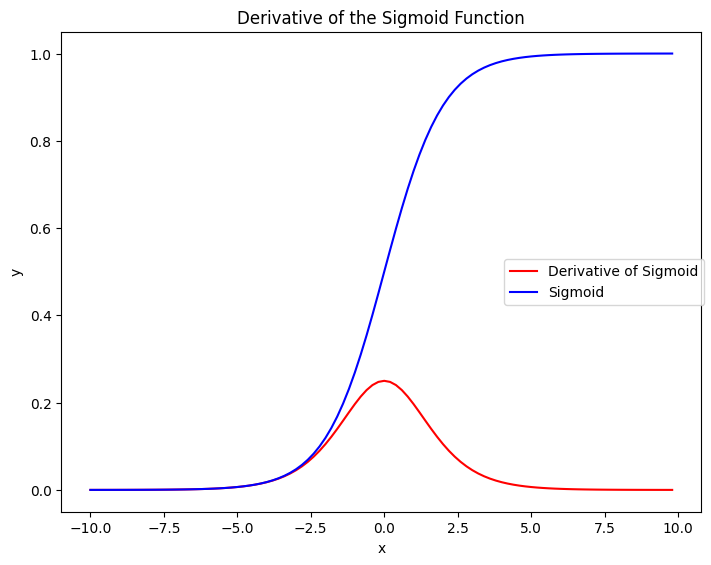

In [15]:
%matplotlib inline
x = np.arange(-10, 10, 0.2)
fig = plt.figure()
ax = fig.add_axes([0, 0, 1, 1])
y = sigmoidDerivative(x)
ax.plot(x, y, color="red", label='Derivative of Sigmoid'.format(1))
y = sigmoid(x)
ax.plot(x, y, color="blue", label='Sigmoid'.format(1))
fig.legend(loc='center right')
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Derivative of the Sigmoid Function")
print()

## Forward- and Backpropagation

We will define a simple network that takes an input as defined for *X* and that generates a corresponding output as defined in *y*. The input array *X* is:

In [16]:
X = np.array( [ [0, 0, 1],
                [0, 1, 1],
                [1, 0, 1],
                [1, 1, 1] ] )

The rows in $X$ are the input vectors for our training or learning phase. Each vector has 3 dimensions.

The output array *y* represents the expected output that the network is expected to learn from the input data. It is defined as a row-vector with 4 rows and 1 column:

In [17]:
y = np.array( [0, 0, 1, 1] ).reshape(-1, 1)
np.shape(y)

(4, 1)

In [18]:
y

array([[0],
       [0],
       [1],
       [1]])

We will define a weight matrix *W* and initialize it with random weights:

In [19]:
W = 2 * np.random.random((3, 1)) - 1
print(W)

[[-0.78707003]
 [ 0.42099049]
 [ 0.72372252]]


In this simple example *W* is the weight matrix that connects two layers, the input (*X*) and the output layer (*O*).

The optimization or learning phase consists of a certain number of iterations that :

In [20]:
iterations = 4000

Let us keep track of the output error (as becomes clear below) in the following variable:

In [21]:
error = 0.0

Repeat for a specific number of iterations the following computations. Initially we take the entire set of training examples in *X* and process them all at the same time. This is called *full batch* training, inidicated by the dot-product between *X* and *W*. Computing *O* is the first prediction step by taking the dot-product of *X* and *W* and computing the sigmoid function over it:

In [22]:
for i in range(iterations):
    O = sigmoid(np.dot(X, W))
    
    O_error = y - O
    error = np.mean(np.abs(O_error))
    if (i % 100) == 0:
        print("Error:", error)
    
    # Compute the delta
    O_delta = O_error * sigmoidDerivative(O)
    
    # update weights
    W += np.dot(X.T, O_delta)

print("O:", O)

Error: 0.5898329888612591
Error: 0.05897193977259261
Error: 0.02906947799798399
Error: 0.019193520984019764
Error: 0.014305387065398646
Error: 0.011394512101525308
Error: 0.009464883371935653
Error: 0.008092621270363032
Error: 0.007067033714641328
Error: 0.006271645573428013
Error: 0.00563686174942356
Error: 0.005118551224181061
Error: 0.004687383190358278
Error: 0.004323105797320768
Error: 0.004011287358320457
Error: 0.003741366663891161
Error: 0.003505437548130988
Error: 0.00329746424625458
Error: 0.0031127593930840762
Error: 0.002947627543856627
Error: 0.0027991160731468514
Error: 0.0026648375299800253
Error: 0.0025428406319756448
Error: 0.0024315150432227123
Error: 0.0023295200480828978
Error: 0.0022357304071599143
Error: 0.0021491947538621998
Error: 0.002069103269491006
Error: 0.0019947623096277325
Error: 0.0019255742985119465
Error: 0.0018610216583071586
Error: 0.0018006538593000115
Error: 0.0017440769062263323
Error: 0.0016909447423984927
Error: 0.0016409521756137041
Error: 0.00

The matrix *X* has 4 rows and 3 columns. The weight matrix *W* has 3 rows and 1 column. The output will be a row vector with 4 rows and 1 column, representing the output that we want to align as close as possible to *y*.

*O_error* is the difference between *y* and the initial guess in *O*. We want to see *O* to reflect *y* as closely as possible. After {{ iterations }} in the loop above, we see that *O* is resembling *y* very well, with an error of {{ error }}.

In the next step we compute the derivative of the sigmoid function for the initial guess vector. The Derivative is weighted by the error, which means that if the slope was shallow (close to or approaching 0), the guess was quite good, that is the network was confident about the output for a given input. If the slope was higher, as for example for *x = 0*, the prediction was not very good. Such bad predictions get updated significantly, while the confident predictions get updated minimally, multiplying them with some small number close to 0.

For every single weight, we 

## Adding a Layer

In the following example we will slightly change the ground truth. Compare the following definition of *y* with the definition above:

In [21]:
y = np.array([[0],
            [1],
            [1],
            [0]])

In the following network specification we introduce a second layer

In [18]:
2 * np.random.random((3, 4)) - 1

array([[-0.62809686, -0.80727697, -0.68681245, -0.32319426],
       [ 0.00332353, -0.90044509, -0.8250264 , -0.36495268],
       [-0.42635273,  0.29295359, -0.94077454,  0.04452739]])

In [19]:
2 * np.random.random((4, 1)) - 1

array([[-0.87829835],
       [ 0.20545786],
       [-0.89181418],
       [-0.46497182]])

In [22]:
np.random.seed(1)

# randomly initialize our weights with mean 0
Wh = 2 * np.random.random((3, 4)) - 1
Wo = 2 * np.random.random((4, 1)) - 1

Xt = X.T # precomputing the transform of X for the loop

for i in range(80000):

    # Feed forward through layers X, H, and O
    H = sigmoid(np.dot(X, Wh))
    O = sigmoid(np.dot(H, Wo))

    # how much did we miss the target value?
    O_error = y - O
    error = np.mean(np.abs(O_error))
    if (i % 10000) == 0:
        print("Error:", error)

    # compute the direction of the optimization for the output layer
    O_delta = O_error * sigmoidDerivative(O)

    # how much did each H value contribute to the O error (according to the weights)?
    H_error = O_delta.dot(Wo.T)
    
    # compute the directions of the optimization for the hidden layer
    H_delta = H_error * sigmoidDerivative(H)

    Wo += H.T.dot(O_delta)
    Wh += Xt.dot(H_delta)

print(O)

Error: 0.4964100319027255
Error: 0.39587723965266564
Error: 0.02824233301196295
Error: 0.009847746184607594
Error: 0.005651708908810978
Error: 0.0037530047998843748
Error: 0.002666343357345524
Error: 0.002020890516544325
[[0.00154211]
 [0.99805794]
 [0.99828371]
 [0.00135254]]


## References

- Goodfellow, Ian, Yoshua Bengio, Aaron Courville (2016). [Deep Learning](http://www.deeplearningbook.org/). MIT Press.
- Nielsen, Michael A. (2015). "Chapter 2: How the backpropagation algorithm works". Neural Networks and Deep Learning. Determination Press.
- Rumelhart, David E., Geoffrey E. Hinton, Ronald J. Williams (1986a). "Learning representations by back-propagating errors". *Nature* 323 (6088): 533–536. [doi:10.1038/323533a0](https://doi.org/10.1038%2F323533a0).
- Rumelhart, David E., Geoffrey E. Hinton, Ronald J. Williams (1986b). "8. Learning Internal Representations by Error Propagation". In: D. Rumelhart, J.L. McClelland (eds.). Parallel Distributed Processing: Explorations in the Microstructure of Cognition. Volume 1: Foundations. Cambridge: MIT Press.

**(C) 2021-2024 by [Damir Cavar](http://damir.cavar.me/) <<dcavar@iu.edu>>**